# 01 - Data Exploration

Phan tich kham pha du lieu Metro Interstate Traffic Volume.

## 1. Doc du lieu

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', palette='Set2')
except ImportError:
    sns = None
    plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

In [2]:
DATA_FILE = 'Metro_Interstate_Traffic_Volume.csv'

candidate_paths = [
    Path.cwd() / '..' / 'data' / 'raw' / DATA_FILE,
    Path.cwd() / 'data' / 'raw' / DATA_FILE,
    Path.cwd() / 'time_series _' / 'data' / 'raw' / DATA_FILE,
]

data_path = next((path.resolve() for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('Khong tim thay file du lieu trong cac duong dan raw data du kien.')

df = pd.read_csv(data_path, parse_dates=['date_time'])
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.00,0.00,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.00,0.00,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.00,0.00,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.00,0.00,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.00,0.00,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


## 2. Kiem tra thong tin tong quan

In [3]:
print(f'Duong dan du lieu: {data_path}')
print(f'So dong: {df.shape[0]:,}')
print(f'So cot: {df.shape[1]:,}')
display(df.head())
display(df.tail())

Duong dan du lieu: D:\Code\Python\time_series _\data\raw\Metro_Interstate_Traffic_Volume.csv
So dong: 48,204
So cot: 9


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.00,0.00,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.00,0.00,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.00,0.00,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.00,0.00,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.00,0.00,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
48199,NaN,283.45,0.00,0.00,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.00,0.00,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.00,0.00,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.00,0.00,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450
48203,NaN,282.12,0.00,0.00,90,Clouds,overcast clouds,2018-09-30 23:00:00,954


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              61 non-null     str           
 1   temp                 48204 non-null  float64       
 2   rain_1h              48204 non-null  float64       
 3   snow_1h              48204 non-null  float64       
 4   clouds_all           48204 non-null  int64         
 5   weather_main         48204 non-null  str           
 6   weather_description  48204 non-null  str           
 7   date_time            48204 non-null  datetime64[us]
 8   traffic_volume       48204 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 4.1 MB


In [5]:
display(df.describe(include='number').T)
display(df.describe(include='object').T)

,count,mean,std,min,25%,50%,75%,max
temp,"48,204.00",281.21,13.34,0.00,272.16,282.45,291.81,310.07
rain_1h,"48,204.00",0.33,44.79,0.00,0.00,0.00,0.00,"9,831.30"
snow_1h,"48,204.00",0.00,0.01,0.00,0.00,0.00,0.00,0.51
clouds_all,"48,204.00",49.36,39.02,0.00,1.00,64.00,90.00,100.00
traffic_volume,"48,204.00","3,259.82","1,986.86",0.00,"1,193.00","3,380.00","4,933.00","7,280.00"


,count,unique,top,freq
holiday,61,11,Labor Day,7
weather_main,48204,11,Clouds,15164
weather_description,48204,38,sky is clear,11665


## 3. Kiem tra cot `date_time`

In [6]:
date_summary = pd.DataFrame({
    'min': [df['date_time'].min()],
    'max': [df['date_time'].max()],
    'so_moc_thoi_gian': [df['date_time'].nunique()],
    'so_dong_trung_date_time': [df.duplicated('date_time').sum()],
    'da_sap_xep_tang_dan': [df['date_time'].is_monotonic_increasing],
})
display(date_summary)

,min,max,so_moc_thoi_gian,so_dong_trung_date_time,da_sap_xep_tang_dan
0,2012-10-02 09:00:00,2018-09-30 23:00:00,40575,7629,True


In [7]:
df = df.sort_values('date_time').reset_index(drop=True)

expected_hourly_index = pd.date_range(df['date_time'].min(), df['date_time'].max(), freq='h')
missing_timestamps = expected_hourly_index.difference(df['date_time'])

print(f'So moc gio ky vong: {len(expected_hourly_index):,}')
print(f'So moc gio bi thieu: {len(missing_timestamps):,}')
display(pd.Series(missing_timestamps[:20], name='missing_date_time').to_frame())

So moc gio ky vong: 52,551
So moc gio bi thieu: 11,976


,missing_date_time
0,2012-10-03 07:00:00
1,2012-10-03 10:00:00
2,2012-10-03 11:00:00
3,2012-10-03 17:00:00
4,2012-10-05 02:00:00
5,2012-10-05 04:00:00
6,2012-10-06 03:00:00
7,2012-10-07 01:00:00
8,2012-10-07 02:00:00
9,2012-10-09 03:00:00


In [8]:
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['day_name'] = df['date_time'].dt.day_name()
df['month'] = df['date_time'].dt.month
df['month_name'] = df['date_time'].dt.month_name()
df['year'] = df['date_time'].dt.year
df['date'] = df['date_time'].dt.date
df['is_weekend'] = df['day_of_week'].isin([5, 6])

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    if month in [3, 4, 5]:
        return 'Spring'
    if month in [6, 7, 8]:
        return 'Summer'
    return 'Autumn'

df['season'] = df['month'].map(get_season)
df[['date_time', 'hour', 'day_name', 'month_name', 'year', 'season']].head()

,date_time,hour,day_name,month_name,year,season
0,2012-10-02 09:00:00,9,Tuesday,October,2012,Autumn
1,2012-10-02 10:00:00,10,Tuesday,October,2012,Autumn
2,2012-10-02 11:00:00,11,Tuesday,October,2012,Autumn
3,2012-10-02 12:00:00,12,Tuesday,October,2012,Autumn
4,2012-10-02 13:00:00,13,Tuesday,October,2012,Autumn


## 4. Kiem tra missing value

In [9]:
missing_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': df.isna().mean() * 100,
}).sort_values('missing_count', ascending=False)
display(missing_summary)

,missing_count,missing_percent
holiday,48143,99.87
temp,0,0.00
rain_1h,0,0.00
snow_1h,0,0.00
clouds_all,0,0.00
weather_main,0,0.00
weather_description,0,0.00
date_time,0,0.00
traffic_volume,0,0.00
hour,0,0.00


## 5. Kiem tra duplicate

In [10]:
print(f'So dong duplicate toan bo: {df.duplicated().sum():,}')
print(f'So dong duplicate theo date_time: {df.duplicated(subset=["date_time"]).sum():,}')

duplicate_rows = df[df.duplicated(keep=False)].sort_values('date_time')
display(duplicate_rows.head(20))

So dong duplicate toan bo: 17
So dong duplicate theo date_time: 7,629


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_of_week,day_name,month,month_name,year,date,is_weekend,season
18696,NaN,286.29,0.00,0.00,1,Clear,sky is clear,2015-09-30 19:00:00,3679,19,2,Wednesday,9,September,2015,2015-09-30,False,Autumn
18697,NaN,286.29,0.00,0.00,1,Clear,sky is clear,2015-09-30 19:00:00,3679,19,2,Wednesday,9,September,2015,2015-09-30,False,Autumn
23850,NaN,289.06,0.00,0.00,90,Clouds,overcast clouds,2016-06-01 10:00:00,4831,10,2,Wednesday,6,June,2016,2016-06-01,False,Summer
23851,NaN,289.06,0.00,0.00,90,Clouds,overcast clouds,2016-06-01 10:00:00,4831,10,2,Wednesday,6,June,2016,2016-06-01,False,Summer
26783,NaN,289.77,0.00,0.00,56,Clouds,broken clouds,2016-09-21 15:00:00,5365,15,2,Wednesday,9,September,2016,2016-09-21,False,Autumn
26784,NaN,289.77,0.00,0.00,56,Clouds,broken clouds,2016-09-21 15:00:00,5365,15,2,Wednesday,9,September,2016,2016-09-21,False,Autumn
26979,NaN,287.86,0.00,0.00,0,Clear,Sky is Clear,2016-09-29 19:00:00,3435,19,3,Thursday,9,September,2016,2016-09-29,False,Autumn
26980,NaN,287.86,0.00,0.00,0,Clear,Sky is Clear,2016-09-29 19:00:00,3435,19,3,Thursday,9,September,2016,2016-09-29,False,Autumn
27171,NaN,279.29,0.00,0.00,56,Clouds,broken clouds,2016-10-07 18:00:00,4642,18,4,Friday,10,October,2016,2016-10-07,False,Autumn
27170,NaN,279.29,0.00,0.00,56,Clouds,broken clouds,2016-10-07 18:00:00,4642,18,4,Friday,10,October,2016,2016-10-07,False,Autumn


## 6. Phan tich `traffic_volume`

,count,mean,std,min,25%,50%,75%,max
traffic_volume,"48,204.00","3,259.82","1,986.86",0.00,"1,193.00","3,380.00","4,933.00","7,280.00"


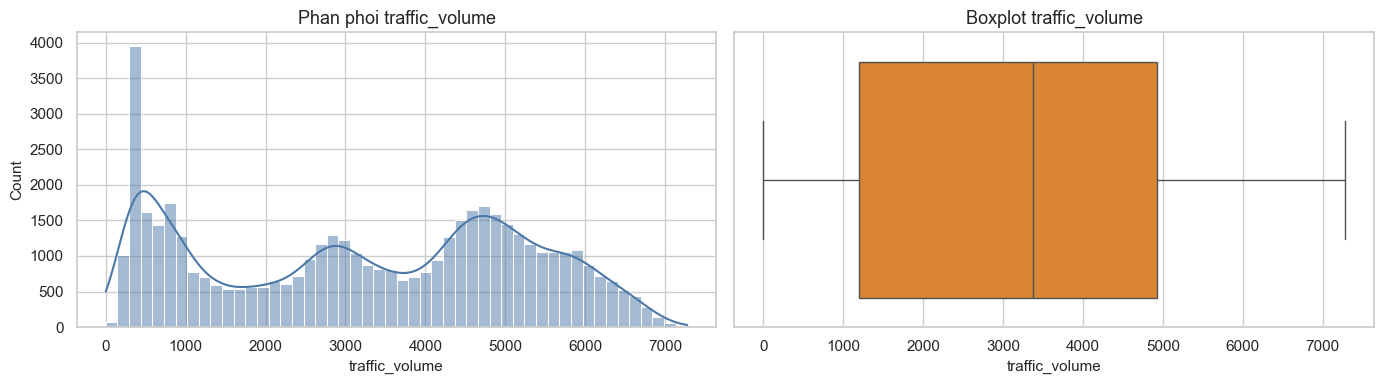

In [11]:
display(df['traffic_volume'].describe().to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
if sns is not None:
    sns.histplot(df['traffic_volume'], bins=50, kde=True, ax=axes[0], color='#4C78A8')
    sns.boxplot(x=df['traffic_volume'], ax=axes[1], color='#F58518')
else:
    axes[0].hist(df['traffic_volume'], bins=50, color='#4C78A8')
    axes[1].boxplot(df['traffic_volume'], vert=False)
axes[0].set_title('Phan phoi traffic_volume')
axes[1].set_title('Boxplot traffic_volume')
plt.tight_layout()
plt.show()

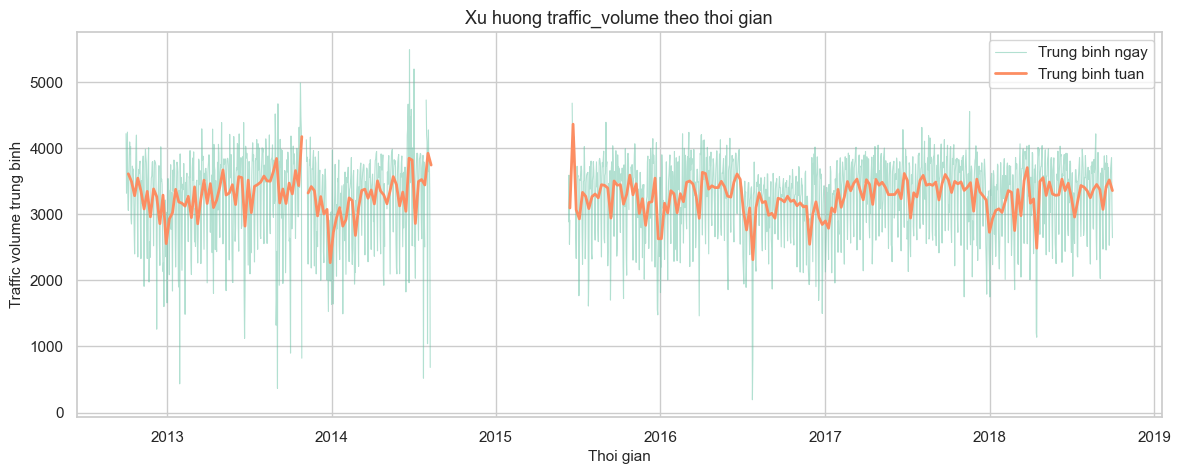

In [12]:
daily_traffic = df.set_index('date_time')['traffic_volume'].resample('D').mean()
weekly_traffic = df.set_index('date_time')['traffic_volume'].resample('W').mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_traffic.index, daily_traffic.values, linewidth=0.8, alpha=0.5, label='Trung binh ngay')
plt.plot(weekly_traffic.index, weekly_traffic.values, linewidth=2, label='Trung binh tuan')
plt.title('Xu huong traffic_volume theo thoi gian')
plt.xlabel('Thoi gian')
plt.ylabel('Traffic volume trung binh')
plt.legend()
plt.show()

## 7. Phan tich outliers

In [13]:
outlier_cols = ['traffic_volume', 'temp', 'rain_1h', 'snow_1h', 'clouds_all']

outlier_summary = []
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_summary.append({
        'column': col,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': int(mask.sum()),
        'outlier_percent': mask.mean() * 100,
        'min': df[col].min(),
        'max': df[col].max(),
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values('outlier_percent', ascending=False)
display(outlier_summary)


,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent,min,max
2,rain_1h,0.00,0.00,0.00,0.00,0.00,3467,7.19,0.00,"9,831.30"
3,snow_1h,0.00,0.00,0.00,0.00,0.00,63,0.13,0.00,0.51
1,temp,272.16,291.81,19.65,242.69,321.27,10,0.02,0.00,310.07
0,traffic_volume,"1,193.00","4,933.00","3,740.00","-4,417.00","10,543.00",0,0.00,0.00,"7,280.00"
4,clouds_all,1.00,90.00,89.00,-132.50,223.50,0,0.00,0.00,100.00


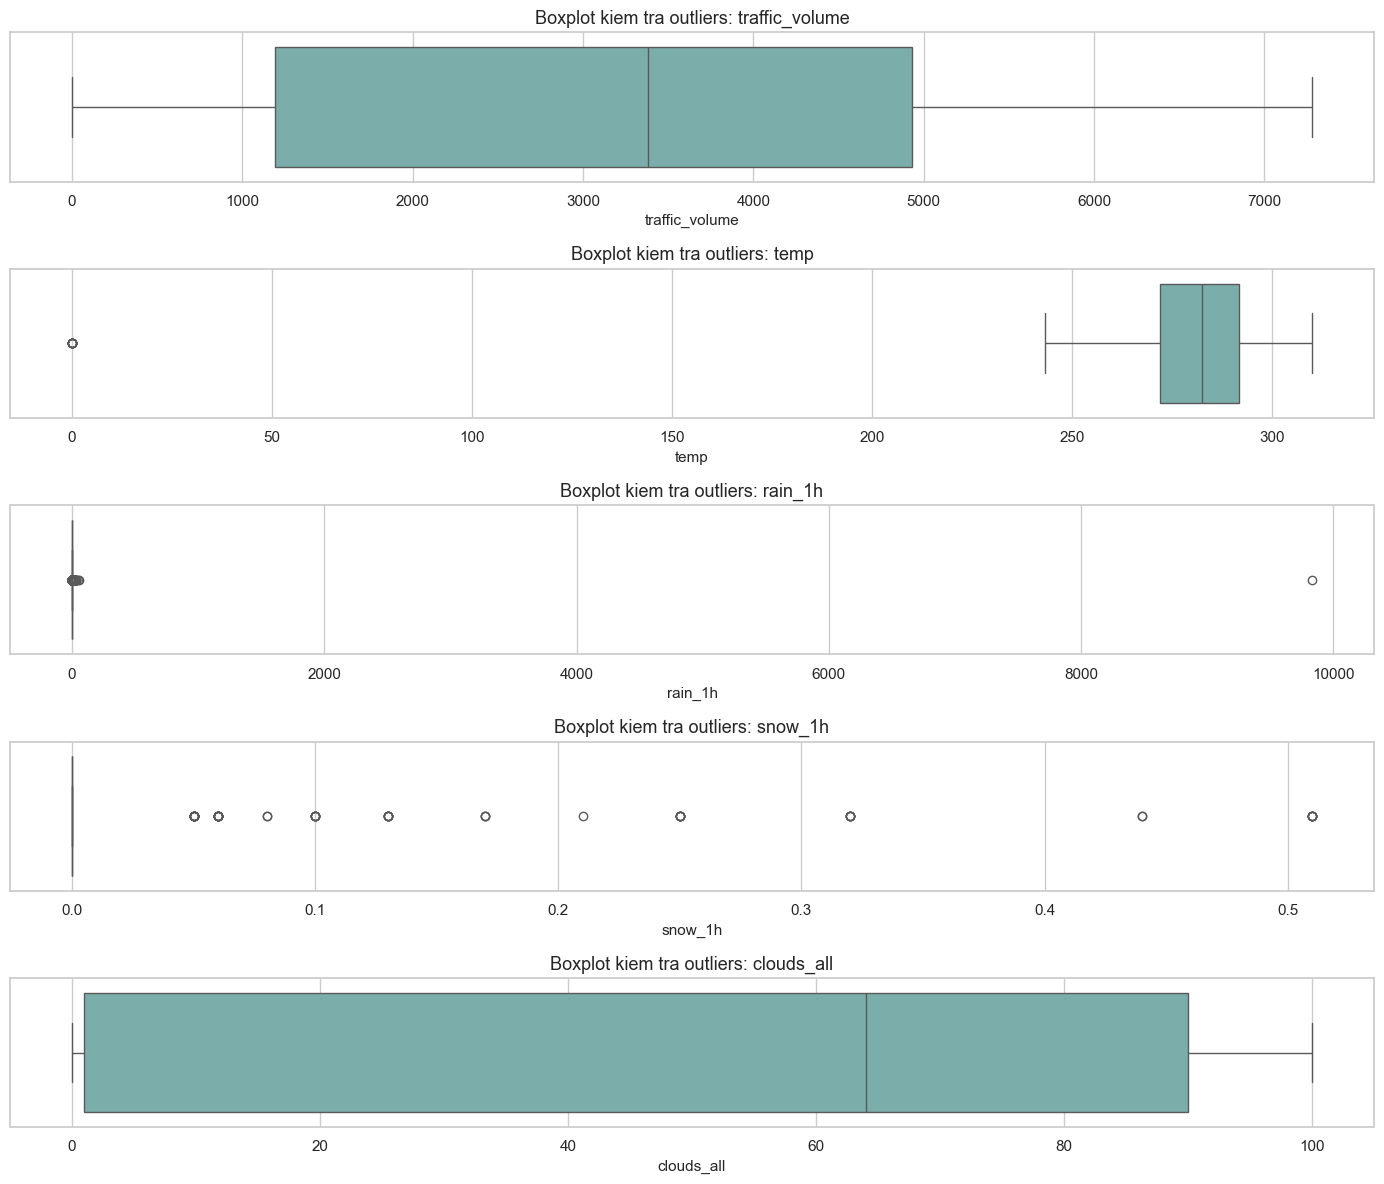

In [14]:
fig, axes = plt.subplots(len(outlier_cols), 1, figsize=(14, 12))

for ax, col in zip(axes, outlier_cols):
    if sns is not None:
        sns.boxplot(data=df, x=col, ax=ax, color='#72B7B2')
    else:
        ax.boxplot(df[col].dropna(), vert=False)
        ax.set_xlabel(col)
    ax.set_title(f'Boxplot kiem tra outliers: {col}')

plt.tight_layout()
plt.show()


In [15]:
traffic_q1 = df['traffic_volume'].quantile(0.25)
traffic_q3 = df['traffic_volume'].quantile(0.75)
traffic_iqr = traffic_q3 - traffic_q1
traffic_lower = traffic_q1 - 1.5 * traffic_iqr
traffic_upper = traffic_q3 + 1.5 * traffic_iqr
traffic_outliers_iqr = df[(df['traffic_volume'] < traffic_lower) | (df['traffic_volume'] > traffic_upper)].copy()

traffic_p01 = df['traffic_volume'].quantile(0.01)
traffic_p99 = df['traffic_volume'].quantile(0.99)
traffic_extreme = df[(df['traffic_volume'] <= traffic_p01) | (df['traffic_volume'] >= traffic_p99)].copy()
zero_traffic = df[df['traffic_volume'] == 0].copy()

print(f'Nguong outlier traffic_volume theo IQR: < {traffic_lower:,.2f} hoac > {traffic_upper:,.2f}')
print(f'So dong outlier traffic_volume theo IQR: {len(traffic_outliers_iqr):,}')
print(f'Nguong cuc tri theo percentile 1%/99%: <= {traffic_p01:,.2f} hoac >= {traffic_p99:,.2f}')
print(f'So dong traffic_volume cuc tri theo percentile: {len(traffic_extreme):,}')
print(f'So dong traffic_volume = 0: {len(zero_traffic):,}')

display(traffic_extreme[['date_time', 'traffic_volume', 'holiday', 'weather_main', 'weather_description', 'hour', 'day_name', 'season']].head(20))

if len(zero_traffic) > 0:
    display(zero_traffic[['date_time', 'traffic_volume', 'holiday', 'weather_main', 'weather_description', 'hour', 'day_name', 'season']].head(20))

display(traffic_extreme.groupby(['hour', 'day_name'])['traffic_volume'].agg(['count', 'mean']).sort_values('count', ascending=False).head(15))


Nguong outlier traffic_volume theo IQR: < -4,417.00 hoac > 10,543.00
So dong outlier traffic_volume theo IQR: 0
Nguong cuc tri theo percentile 1%/99%: <= 257.00 hoac >= 6,701.97
So dong traffic_volume cuc tri theo percentile: 977
So dong traffic_volume = 0: 2


,date_time,traffic_volume,holiday,weather_main,weather_description,hour,day_name,season
42,2012-10-04 07:00:00,6990,NaN,Clear,sky is clear,7,Thursday,Autumn
152,2012-10-09 02:00:00,251,NaN,Clear,sky is clear,2,Tuesday,Autumn
178,2012-10-10 07:00:00,6793,NaN,Rain,light rain,7,Wednesday,Autumn
179,2012-10-10 07:00:00,6793,NaN,Drizzle,light intensity drizzle,7,Wednesday,Autumn
202,2012-10-11 07:00:00,6798,NaN,Clear,sky is clear,7,Thursday,Autumn
223,2012-10-12 07:00:00,6992,NaN,Clouds,broken clouds,7,Friday,Autumn
300,2012-10-15 02:00:00,239,NaN,Fog,fog,2,Monday,Autumn
308,2012-10-15 07:00:00,6798,NaN,Mist,mist,7,Monday,Autumn
327,2012-10-16 02:00:00,257,NaN,Clear,sky is clear,2,Tuesday,Autumn
332,2012-10-16 07:00:00,7055,NaN,Clouds,few clouds,7,Tuesday,Autumn


,date_time,traffic_volume,holiday,weather_main,weather_description,hour,day_name,season
25186,2016-07-23 18:00:00,0,NaN,Rain,light rain,18,Saturday,Summer
25191,2016-07-23 23:00:00,0,NaN,Haze,haze,23,Saturday,Summer


count     mean
hour day_name                 
2    Tuesday      144   237.70
     Monday        87   233.98
16   Wednesday     68 6,835.26
     Thursday      67 6,841.84
     Tuesday       61 6,839.84
7    Wednesday     60 6,900.50
2    Wednesday     59   243.25
7    Tuesday       55 6,872.07
     Thursday      54 6,865.22
2    Thursday      51   237.10
7    Monday        42 6,836.36
4    Sunday        35   207.83
7    Friday        33 6,805.33
3    Sunday        16   170.19
16   Monday        13 6,836.38

## 8. Phan tich `traffic_volume` theo gio, thu, thang, nam

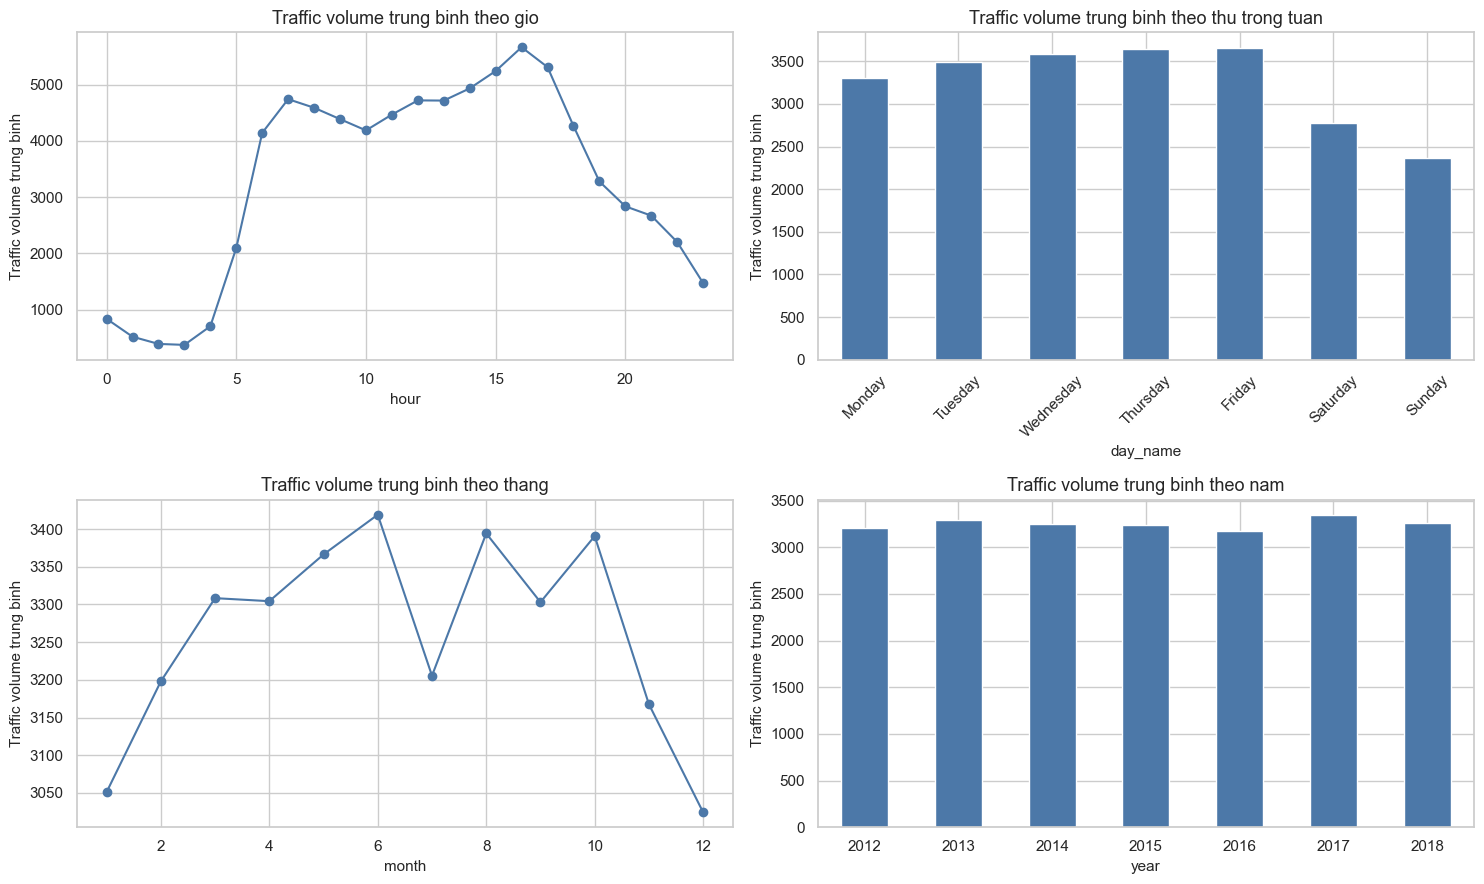

In [16]:
time_groups = {
    'hour': df.groupby('hour')['traffic_volume'].mean(),
    'day_name': df.groupby('day_name')['traffic_volume'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']),
    'month': df.groupby('month')['traffic_volume'].mean(),
    'year': df.groupby('year')['traffic_volume'].mean(),
}

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.ravel()
titles = ['Theo gio', 'Theo thu trong tuan', 'Theo thang', 'Theo nam']

for ax, (name, values), title in zip(axes, time_groups.items(), titles):
    if name in ['day_name', 'year']:
        values.plot(kind='bar', ax=ax, color='#4C78A8')
    else:
        values.plot(kind='line', marker='o', ax=ax, color='#4C78A8')
    ax.set_title(f'Traffic volume trung binh {title.lower()}')
    ax.set_xlabel(name)
    ax.set_ylabel('Traffic volume trung binh')
    ax.tick_params(axis='x', rotation=45 if name == 'day_name' else 0)

plt.tight_layout()
plt.show()


In [17]:
summary_by_time = pd.concat(
    [
        df.groupby('hour')['traffic_volume'].agg(['count', 'mean', 'median', 'std']).assign(group='hour'),
        df.groupby('day_name')['traffic_volume'].agg(['count', 'mean', 'median', 'std']).assign(group='day_name'),
        df.groupby('month')['traffic_volume'].agg(['count', 'mean', 'median', 'std']).assign(group='month'),
        df.groupby('year')['traffic_volume'].agg(['count', 'mean', 'median', 'std']).assign(group='year'),
    ],
    keys=['hour', 'day_name', 'month', 'year']
)
display(summary_by_time)

count     mean   median      std     group
hour     0           2037   834.78   676.00   380.96      hour
         1           2049   516.45   420.00   227.10      hour
         2           2019   388.35   315.00   168.20      hour
         3           2025   371.09   362.00    67.19      hour
         4           2091   702.55   807.00   233.88      hour
         5           2063 2,094.57 2,638.00 1,008.38      hour
         6           2087 4,140.50 5,381.00 2,073.22      hour
         7           2079 4,740.18 5,998.00 2,215.39      hour
         8           2080 4,587.50 5,440.50 1,669.28      hour
         9           2018 4,385.28 4,839.00 1,048.46      hour
         10          2078 4,184.67 4,366.00   611.84      hour
         11          1952 4,465.88 4,577.00   618.27      hour
         12          1955 4,718.29 4,819.00   603.47      hour
         13          1905 4,714.94 4,805.00   607.29      hour
         14          1969 4,931.89 5,065.00   650.45      hour
         15          1934 5,240.52 5,554.00   810.85      hour
         16          1988 5,663.76 6,167.00 1,108.99      hour
         17          1933 5,310.08 5,719.00 1,028.29      hour
         18          1986 4,263.72 4,383.50   630.71      hour
         19          1961 3,276.39 3,326.00   458.08      hour
         20          1979 2,834.67 2,866.00   427.49      hour
         21          1982 2,668.94 2,649.00   526.09      hour
         22          1994 2,199.41 2,050.50   677.50      hour
         23          2040 1,469.14 1,250.00   590.81      hour
day_name Friday      6836 3,656.36 4,331.00 2,025.19  day_name
         Monday      7072 3,309.39 3,623.50 2,016.97  day_name
         Saturday    6831 2,773.64 3,003.00 1,582.45  day_name
         Sunday      6872 2,368.59 2,260.50 1,482.67  day_name
         Thursday    6817 3,637.90 4,280.00 2,096.86  day_name
         Tuesday     6846 3,488.56 4,070.00 2,099.00  day_name
         Wednesday   6930 3,583.20 4,315.00 2,112.81  day_name
month    1           4006 3,051.08 3,089.50 1,908.01     month
         2           3526 3,197.95 3,306.00 1,975.13     month
         3           3793 3,308.39 3,510.00 2,027.31     month
         4           4259 3,304.37 3,340.00 2,069.51     month
         5           4436 3,366.32 3,463.00 2,032.46     month
         6           3772 3,419.08 3,652.50 1,974.98     month
         7           4795 3,205.48 3,268.00 1,940.09     month
         8           4378 3,394.24 3,648.50 1,988.36     month
         9           3831 3,303.05 3,477.00 1,997.36     month
         10          3473 3,390.68 3,713.00 2,003.30     month
         11          3686 3,167.59 3,149.00 2,003.65     month
         12          4249 3,024.26 3,055.00 1,877.19     month
year     2012        2559 3,207.80 3,225.00 1,990.62      year
         2013        8573 3,286.76 3,344.00 2,028.32      year
         2014        4839 3,250.94 3,316.00 1,999.00      year
         2015        4373 3,242.90 3,368.00 1,990.12      year
         2016        9306 3,169.44 3,258.50 1,947.41      year
         2017       10605 3,340.70 3,530.00 1,986.51      year
         2018        7949 3,260.11 3,400.00 1,973.09      year

## 9. Phan tich mua vu

,count,mean,median,std
season,,,,
Spring,12488,"3,327.60","3,443.00","2,043.65"
Summer,12945,"3,331.56","3,493.00","1,968.95"
Autumn,10990,"3,285.31","3,449.50","2,003.23"
Winter,11781,"3,085.36","3,135.00","1,918.68"


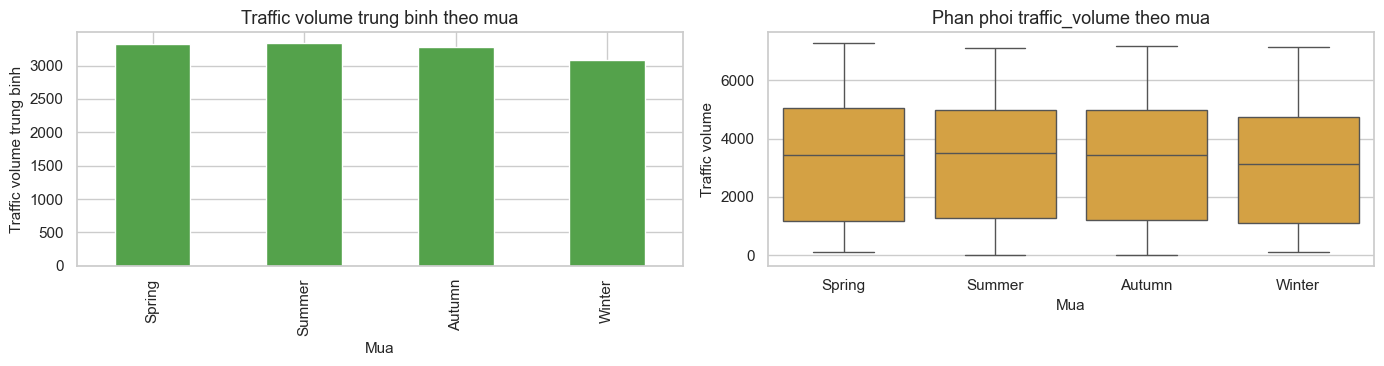

In [18]:
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
season_summary = df.groupby('season')['traffic_volume'].agg(['count', 'mean', 'median', 'std']).reindex(season_order)
display(season_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
season_summary['mean'].plot(kind='bar', ax=axes[0], color='#54A24B')
axes[0].set_title('Traffic volume trung binh theo mua')
axes[0].set_xlabel('Mua')
axes[0].set_ylabel('Traffic volume trung binh')
if sns is not None:
    sns.boxplot(data=df, x='season', y='traffic_volume', order=season_order, ax=axes[1], color='#ECA82C')
else:
    df.boxplot(column='traffic_volume', by='season', ax=axes[1])
axes[1].set_title('Phan phoi traffic_volume theo mua')
axes[1].set_xlabel('Mua')
axes[1].set_ylabel('Traffic volume')
plt.suptitle('')
plt.tight_layout()
plt.show()

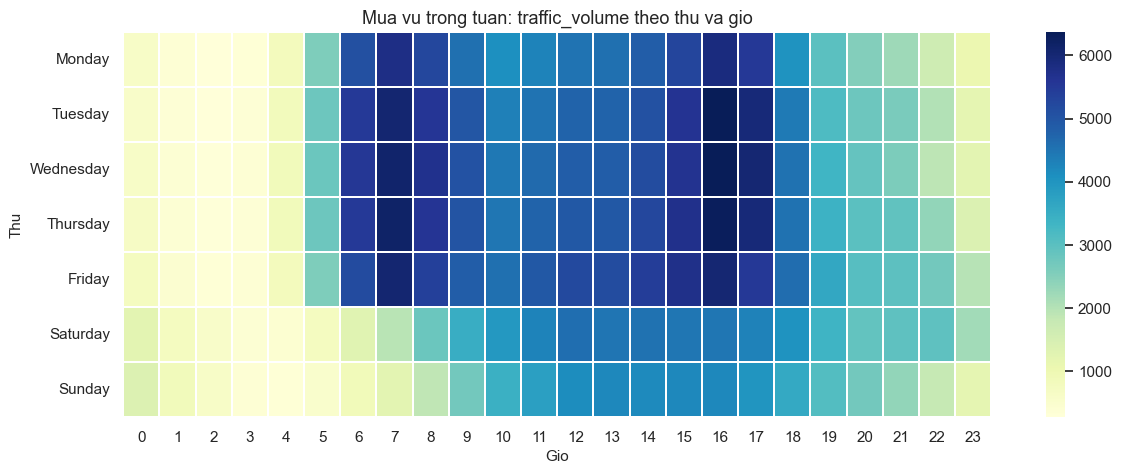

In [19]:
hour_weekday_pivot = df.pivot_table(index='day_name', columns='hour', values='traffic_volume', aggfunc='mean')
hour_weekday_pivot = hour_weekday_pivot.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(14, 5))
if sns is not None:
    sns.heatmap(hour_weekday_pivot, cmap='YlGnBu', linewidths=0.2)
else:
    plt.imshow(hour_weekday_pivot, aspect='auto', cmap='YlGnBu')
    plt.colorbar(label='Traffic volume trung binh')
    plt.yticks(range(len(hour_weekday_pivot.index)), hour_weekday_pivot.index)
    plt.xticks(range(len(hour_weekday_pivot.columns)), hour_weekday_pivot.columns)
plt.title('Mua vu trong tuan: traffic_volume theo thu va gio')
plt.xlabel('Gio')
plt.ylabel('Thu')
plt.show()

## 10. Phan tich bien thoi tiet

,count,mean,std,min,25%,50%,75%,max
temp,"48,204.00",281.21,13.34,0.00,272.16,282.45,291.81,310.07
rain_1h,"48,204.00",0.33,44.79,0.00,0.00,0.00,0.00,"9,831.30"
snow_1h,"48,204.00",0.00,0.01,0.00,0.00,0.00,0.00,0.51
clouds_all,"48,204.00",49.36,39.02,0.00,1.00,64.00,90.00,100.00


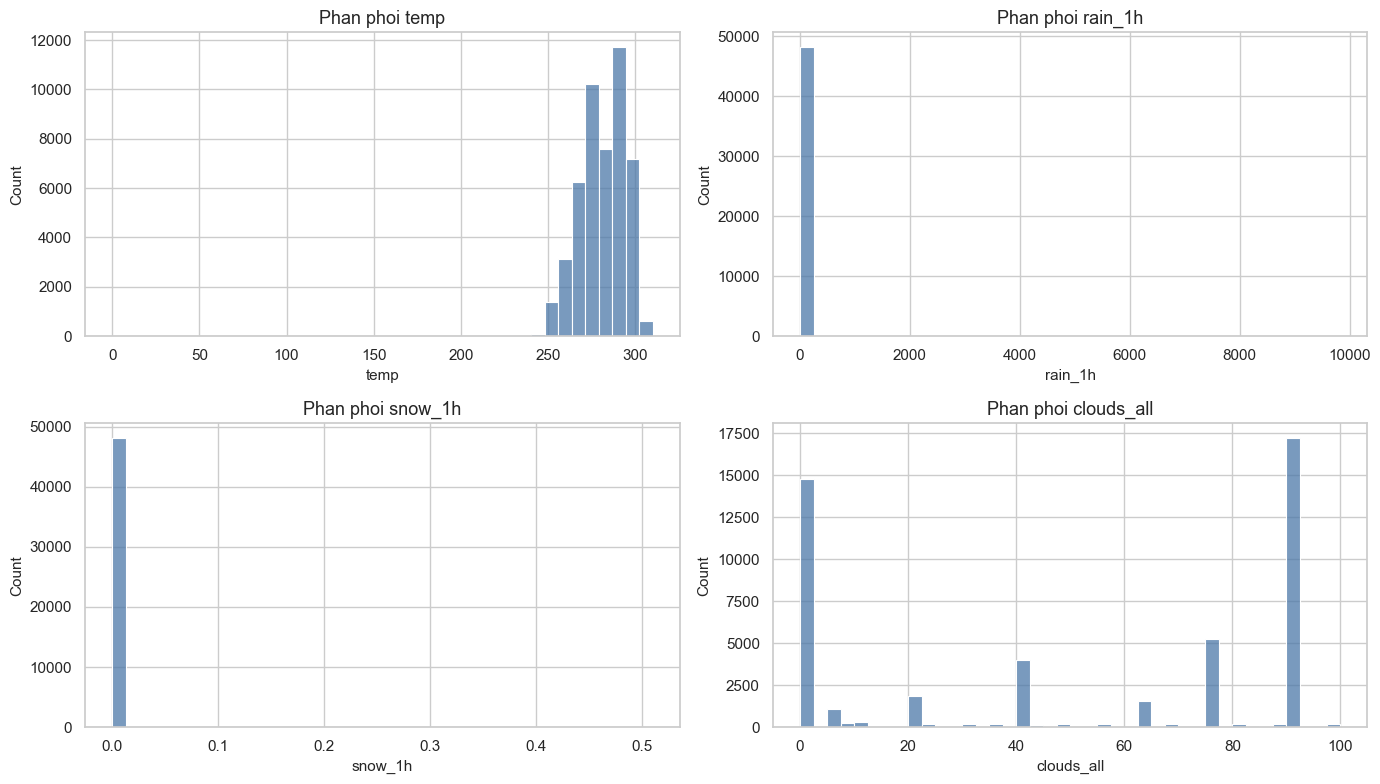

In [20]:
weather_numeric_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all']
display(df[weather_numeric_cols].describe().T)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), weather_numeric_cols):
    if sns is not None:
        sns.histplot(df[col], bins=40, ax=ax, color='#4C78A8')
    else:
        ax.hist(df[col], bins=40, color='#4C78A8')
    ax.set_title(f'Phan phoi {col}')
plt.tight_layout()
plt.show()

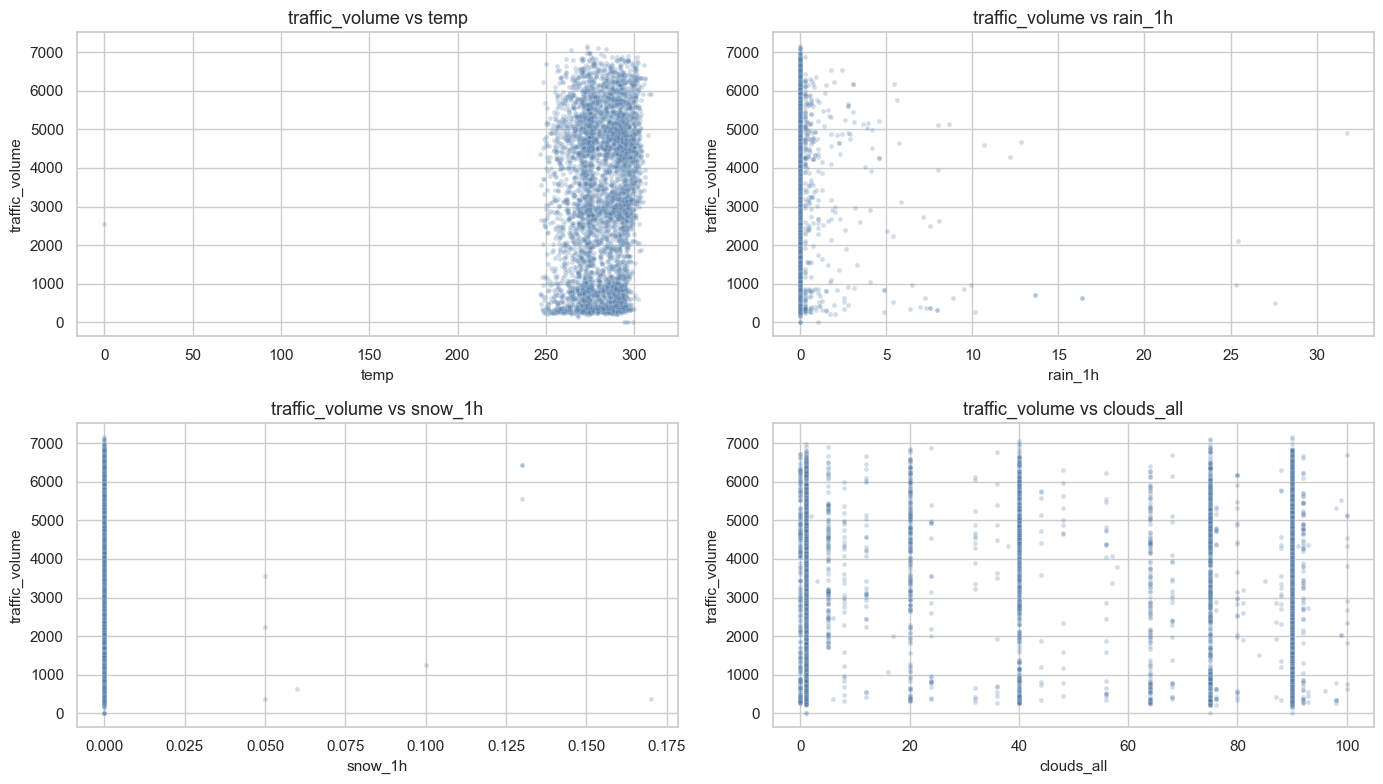

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), weather_numeric_cols):
    sample = df.sample(min(5000, len(df)), random_state=42)
    if sns is not None:
        sns.scatterplot(data=sample, x=col, y='traffic_volume', alpha=0.25, s=12, ax=ax, color='#4C78A8')
    else:
        ax.scatter(sample[col], sample['traffic_volume'], alpha=0.25, s=12, color='#4C78A8')
    ax.set_title(f'traffic_volume vs {col}')
plt.tight_layout()
plt.show()

## 11. Phan tich bien phan loai

In [22]:
categorical_cols = ['holiday', 'weather_main', 'weather_description']

for col in categorical_cols:
    print(f'Cot {col}: {df[col].nunique()} gia tri duy nhat')
    display(df[col].value_counts(dropna=False).head(20).to_frame('count'))

Cot holiday: 11 gia tri duy nhat


,count
holiday,
NaN,48143
Labor Day,7
Thanksgiving Day,6
Christmas Day,6
New Years Day,6
Martin Luther King Jr Day,6
Columbus Day,5
Veterans Day,5
Washingtons Birthday,5


Cot weather_main: 11 gia tri duy nhat


,count
weather_main,
Clouds,15164
Clear,13391
Mist,5950
Rain,5672
Snow,2876
Drizzle,1821
Haze,1360
Thunderstorm,1034
Fog,912


Cot weather_description: 38 gia tri duy nhat


,count
weather_description,
sky is clear,11665
mist,5950
overcast clouds,5081
broken clouds,4666
scattered clouds,3461
light rain,3372
few clouds,1956
light snow,1946
Sky is Clear,1726


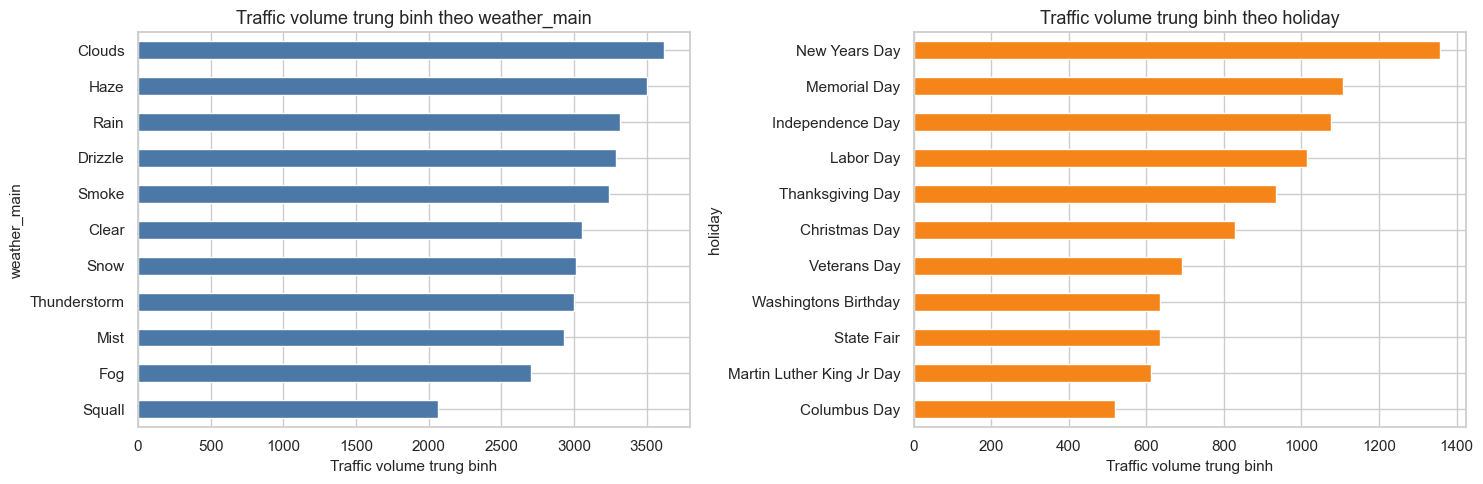

,count,mean
weather_main,,
Squall,4,"2,061.75"
Fog,912,"2,703.72"
Mist,5950,"2,932.96"
Thunderstorm,1034,"3,001.62"
Snow,2876,"3,016.84"
Clear,13391,"3,055.91"
Smoke,20,"3,237.65"
Drizzle,1821,"3,290.73"
Rain,5672,"3,317.91"


,count,mean
holiday,,
Columbus Day,5,519.40
Martin Luther King Jr Day,6,612.67
State Fair,5,634.80
Washingtons Birthday,5,635.20
Veterans Day,5,691.40
Christmas Day,6,827.50
Thanksgiving Day,6,933.50
Labor Day,7,"1,013.14"
Independence Day,5,"1,076.00"


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
weather_main_summary = df.groupby('weather_main')['traffic_volume'].agg(['count', 'mean']).sort_values('mean')
weather_main_summary['mean'].plot(kind='barh', ax=axes[0], color='#4C78A8')
axes[0].set_title('Traffic volume trung binh theo weather_main')
axes[0].set_xlabel('Traffic volume trung binh')

holiday_summary = df.groupby('holiday')['traffic_volume'].agg(['count', 'mean']).sort_values('mean')
holiday_summary['mean'].tail(15).plot(kind='barh', ax=axes[1], color='#F58518')
axes[1].set_title('Traffic volume trung binh theo holiday')
axes[1].set_xlabel('Traffic volume trung binh')
plt.tight_layout()
plt.show()

display(weather_main_summary)
display(holiday_summary)

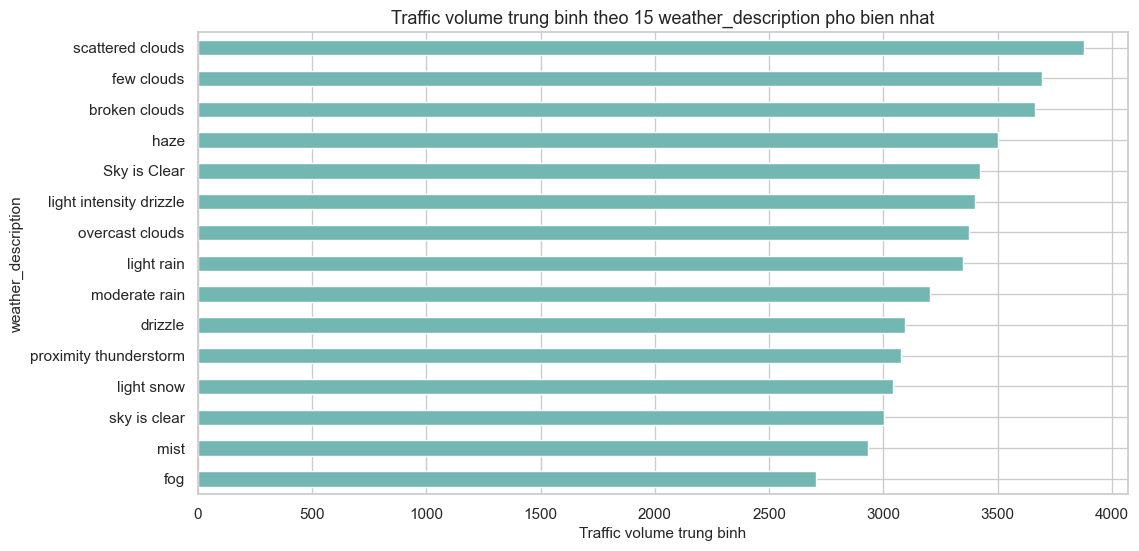

,count,mean,median
weather_description,,,
fog,912,"2,703.72","2,339.00"
mist,5950,"2,932.96","2,800.00"
sky is clear,11665,"3,001.57","2,982.00"
light snow,1946,"3,042.77","3,157.50"
proximity thunderstorm,673,"3,076.46","3,064.00"
drizzle,651,"3,094.86","3,024.00"
moderate rain,1664,"3,202.60","3,199.00"
light rain,3372,"3,349.26","3,590.50"
overcast clouds,5081,"3,375.96","3,568.00"


In [24]:
top_weather_desc = df['weather_description'].value_counts().head(15).index
weather_desc_summary = (
    df[df['weather_description'].isin(top_weather_desc)]
    .groupby('weather_description')['traffic_volume']
    .agg(['count', 'mean', 'median'])
    .sort_values('mean')
)

weather_desc_summary['mean'].plot(kind='barh', figsize=(12, 6), color='#72B7B2')
plt.title('Traffic volume trung binh theo 15 weather_description pho bien nhat')
plt.xlabel('Traffic volume trung binh')
plt.show()
display(weather_desc_summary)

## 12. Phan tich tuong quan

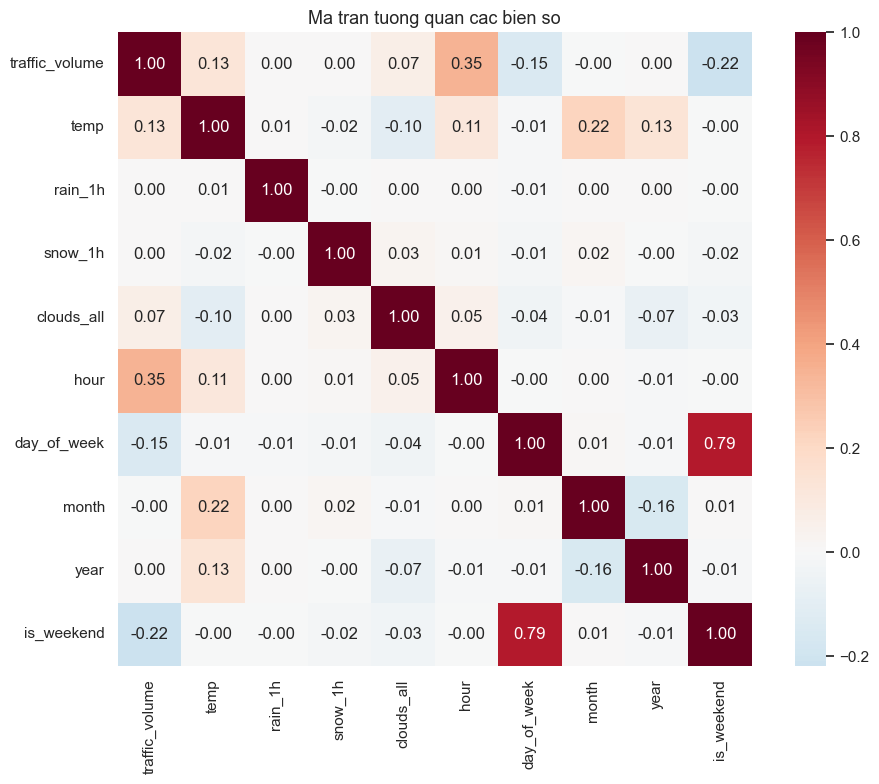

,corr_with_traffic_volume
traffic_volume,1.00
hour,0.35
temp,0.13
clouds_all,0.07
year,0.00
rain_1h,0.00
snow_1h,0.00
month,-0.00
day_of_week,-0.15
is_weekend,-0.22


In [25]:
corr_cols = ['traffic_volume', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month', 'year', 'is_weekend']
corr_df = df[corr_cols].copy()
corr_df['is_weekend'] = corr_df['is_weekend'].astype(int)
corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
if sns is not None:
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
else:
    plt.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(label='Correlation')
    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title('Ma tran tuong quan cac bien so')
plt.tight_layout()
plt.show()

display(corr_matrix['traffic_volume'].sort_values(ascending=False).to_frame('corr_with_traffic_volume'))

In [26]:
encoded_corr_df = pd.get_dummies(
    df[['traffic_volume', 'weather_main', 'holiday', 'season', 'hour', 'day_of_week', 'month']].copy(),
    columns=['weather_main', 'holiday', 'season'],
    drop_first=False,
)

encoded_corr = encoded_corr_df.corr(numeric_only=True)['traffic_volume'].sort_values(key=lambda s: s.abs(), ascending=False)
display(encoded_corr.head(25).to_frame('corr_with_traffic_volume'))

,corr_with_traffic_volume
traffic_volume,1.00
hour,0.35
day_of_week,-0.15
weather_main_Clouds,0.12
weather_main_Clear,-0.06
weather_main_Mist,-0.06
season_Winter,-0.05
weather_main_Fog,-0.04
weather_main_Snow,-0.03
season_Summer,0.02
